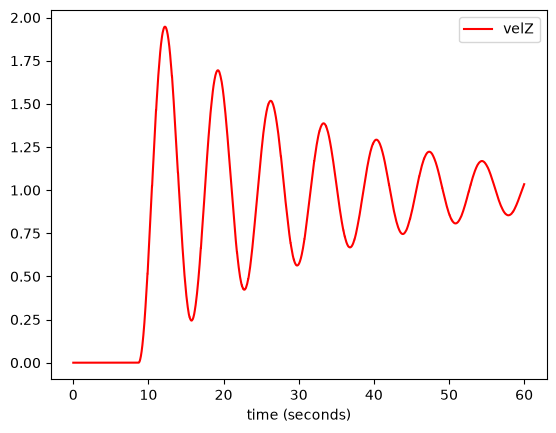

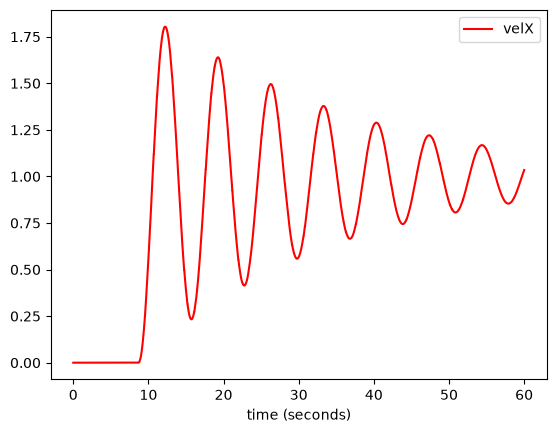

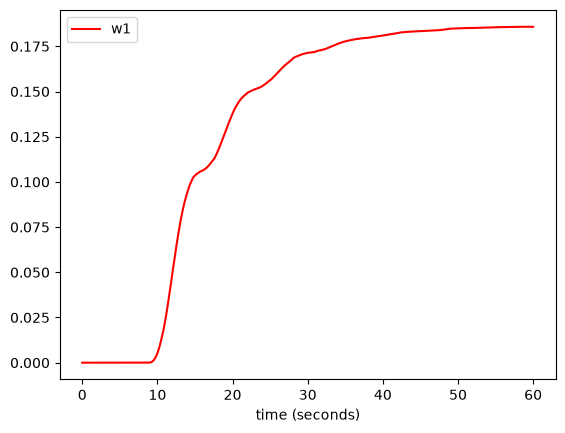

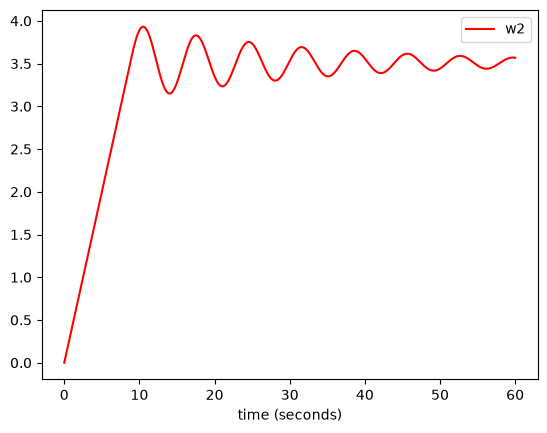

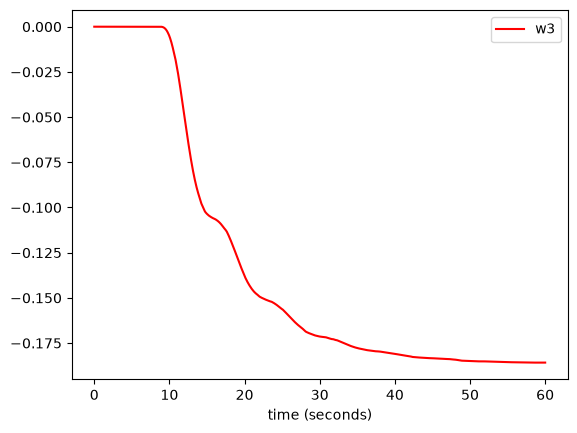

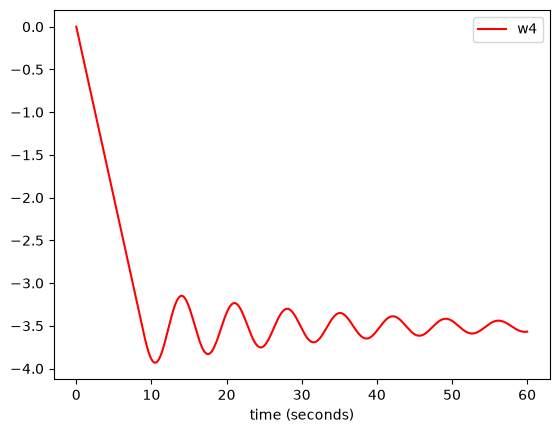

In [23]:
from lib.dds import *
from lib.time import *
from lib.dataplot import *
import numpy as np

class Proportional:
    def __init__(self,k):
        self.k = k

    def evaluate(self,delta_t,u):
        return u * self.k

class Integrator:
    def __init__(self):
        self.acc = 0

    def evaluate(self, delta_t, u):
        out = self.acc + u * delta_t
        self.acc = out
        return out

class PI:
    def __init__(self, k , ki, sat):
        self.P = Proportional(k)
        self.I = Integrator()
        self.ki = ki
        self.sat = sat

    def evaluate(self, delta_t, u):
        out_p = self.P.evaluate(delta_t,u)
        out_i = self.ki * self.I.evaluate(delta_t,out_p)
        if out_i > self.sat:
            out_i = self.sat
        return out_i

def inv_kin(v,r,l):
    return  (1/r) * np.dot([[-1,1,- 1 * l],[1,1,- 1 * l],[1,-1,- 1 * l],[-1,-1,- 1 * l]],v)

class MecanumController:
    def __init__(self, k, ki, sat, R, L):
        self.PI_w1 = PI(k,ki,sat) 
        self.PI_w2 = PI(k,ki,sat)
        self.PI_w3 = PI(k,ki,sat)
        self.PI_w4 = PI(k,ki,sat)
        self.R = R
        self.L = L
        self.target = [0,0,0,0]

    def set_target(self,v):
        self.target = inv_kin(v,self.R,self.L)

    def evaluate(self, delta_t, u):
        v = inv_kin(u,self.R,self.L)
        err =  self.target - v
        w1 = self.PI_w1.evaluate(delta_t,err[0])
        w2 = self.PI_w2.evaluate(delta_t,err[1])
        w3 = self.PI_w3.evaluate(delta_t,err[2])
        w4 = self.PI_w4.evaluate(delta_t,err[3])
        return [w1,w2,w3,w4]

dpx = DataPlotter()
dpx.set_x("time (seconds)")
dpx.add_y("posX", "posX")
dpz = DataPlotter()
dpz.set_x("time (seconds)")
dpz.add_y("posZ", "posZ")

dp_vz = DataPlotter()
dp_vz.set_x("time (seconds)")
dp_vz.add_y("velZ","velZ")
dp_vx = DataPlotter()
dp_vx.set_x("time (seconds)")
dp_vx.add_y("velX","velX")

dp_w1 = DataPlotter()
dp_w1.set_x("time (seconds)")
dp_w1.add_y("w1", "w1")
dp_w2 = DataPlotter()
dp_w2.set_x("time (seconds)")
dp_w2.add_y("w2", "w2")
dp_w3 = DataPlotter()
dp_w3.set_x("time (seconds)")
dp_w3.add_y("w3", "w3")
dp_w4 = DataPlotter()
dp_w4.set_x("time (seconds)")
dp_w4.add_y("w4", "w4")

dds = DDS()
dds.start()

dds.subscribe(["posX", "posZ","velZ","velX"])

m = MecanumController(4, 0.05, 10, 1, 1)


#value = m.evaluate(1,[-3,3,-0.05])
m.set_target([1,1,0])
t = Time()
t.start()

while t.get() < 60:
    delta_t = t.elapsed()
    velZ = dds.wait("velZ")
    velX = dds.wait("velX")
    posZ = dds.wait("posZ")
    posX = dds.wait("posX")

    w = m.evaluate(delta_t,[velZ,velX,0])

    dds.publish("w1",w[0],dds.DDS_TYPE_FLOAT)
    dds.publish("w2",w[1],dds.DDS_TYPE_FLOAT)
    dds.publish("w3",w[2],dds.DDS_TYPE_FLOAT)
    dds.publish("w4",w[3],dds.DDS_TYPE_FLOAT)

    dp_vz.append_x(t.get())
    dp_vz.append_y("velZ",velZ)
    dp_vx.append_x(t.get())
    dp_vx.append_y("velX",velX)
    
    dpx.append_x(t.get())
    dpx.append_y("posX", posX)
    dpz.append_x(t.get())
    dpz.append_y("posZ", posZ)

    dp_w1.append_x(t.get())
    dp_w1.append_y("w1", w[0])
    dp_w2.append_x(t.get())
    dp_w2.append_y("w2", w[1])
    dp_w3.append_x(t.get())
    dp_w3.append_y("w3", w[2])
    dp_w4.append_x(t.get())
    dp_w4.append_y("w4", w[3])


#dpx.plot()
#dpz.plot()
dp_vz.plot()
dp_vx.plot()

dp_w1.plot()
dp_w2.plot()
dp_w3.plot()
dp_w4.plot()


dds.stop()